# Stress test: efficiency of Eclypse+NET

This notebook runs the benchmark of `stress_test.py` and analyses the efficiency of the
network extension with dedicated charts.

**Scenario.** A Fat-Tree with parameter `k` (from the ECLYPSE `get_fat_tree` builder) is
simulated twice for 50 steps:

- **ECLYPSE base**: the plain `Infrastructure`, with one service per host and no
  network events. This is the cost of the simulation framework alone.
- **Eclypse+NET**: the same topology as a `Network` (1 Gbps, 1 km links, queues of
  100 000 packets), where the first host sends Poisson traffic of 1500-byte packets to
  every other host, with a total rate from 10 to 1500 packets per step.

On top of the wall-clock time measured by the script, the notebook instruments the three
network events to record how long each of them takes at every step and how many hops the
routing event simulates. This makes it possible to separate the fixed cost of the
extension from the cost that grows with traffic.

> The outputs stored in this notebook come from a run on a generic cloud machine. Absolute
> times depend on the hardware: re-run the notebook to measure your own machine.

## Setup

In [1]:
import random
import shutil
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

from eclypse.builders.infrastructure.generators import get_fat_tree
from eclypse.graph import Application, Infrastructure
from eclypse.network import (
    Network,
    NetworkApplication,
    PacketGenerationEvent,
    RoutingEvent,
    RoutingMetric,
)
from eclypse.placement._manager import PlacementManager
from eclypse.placement.strategies import StaticStrategy
from eclypse.simulation import Simulation, SimulationConfig

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# Benchmark configuration (the same as stress_test.py)
K_VALUES = [6, 8, 10, 12]
RATES = [10, 100, 300, 600, 900, 1200, 1500]  # packets per step, in total
PACKET_SIZE = 1500  # bytes
SIM_STEPS = 50
NUM_RUNS = 1  # repetitions of each configuration; times are averaged

RESULTS = Path("./results_stress_test")
shutil.rmtree(RESULTS, ignore_errors=True)

# Chart style: light surface, recessive axes and grid
SURFACE, TEXT, TEXT_MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT_MUTED,
    "axes.titlecolor": TEXT,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": TEXT_MUTED,
    "ytick.color": TEXT_MUTED,
    "legend.frameon": False,
    "legend.labelcolor": TEXT,
    "font.size": 10,
})

# One color and one marker per Fat-Tree size
K_STYLE = {
    6: {"color": "#2a78d6", "marker": "o"},
    8: {"color": "#eb6834", "marker": "s"},
    10: {"color": "#1baf7a", "marker": "^"},
    12: {"color": "#eda100", "marker": "D"},
}


def fat_tree_nodes(k):
    return 5 * k * k // 4 + k**3 // 4


def k_label(k):
    return f"k = {k} ({fat_tree_nodes(k)} nodes)"

## Instrumented events

`Timed` wraps the `__call__` of an event and records its duration at every step. It is
applied to the packet generation and routing events; the routing event also records the number of telemetry rows of the step, which is the
number of simulated hops (one per packet forwarded or dropped), and the drops.
The events keep their names, so the simulation and the reports are unchanged.
`RoutingMetric` is left as it is: ECLYPSE wraps metric classes in a decorator, so they
cannot be extended by subclassing, and its time is counted with the framework.

In [2]:
class Timed:
    # Mixin that records the wall-clock duration of every call of an event
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.durations = []

    def __call__(self, *args, **kwargs):
        start = time.perf_counter()
        out = super().__call__(*args, **kwargs)
        self.durations.append(time.perf_counter() - start)
        return out


class TimedPacketGeneration(Timed, PacketGenerationEvent):
    pass


class TimedRouting(Timed, RoutingEvent):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.hops = []
        self.drops = []

    def __call__(self, app, placement, infra, **kwargs):
        out = super().__call__(app, placement, infra, **kwargs)
        columns = infra.step_columns
        self.hops.append(len(columns["hop"]))
        self.drops.append(int(sum(columns["dropped"])))
        return out

Two methods of the ECLYPSE framework are also timed, by wrapping them on their class:

- `PlacementManager.audit`, which at every step checks that each placed application
  still satisfies its requirements, including the latency and bandwidth of the path of
  every application link;
- `Infrastructure._compute_path`, which (re)computes one of those paths. ECLYPSE caches
  paths and recomputes one when the `latency` of one of its links changes beyond a
  threshold, and the routing event updates link latencies at every step.

Both are internal methods, used here only for measurement.

In [3]:
FRAMEWORK = {"audit_s": 0.0, "path_s": 0.0, "path_calls": 0}


def instrument(cls, method, time_key, count_key=None):
    original = getattr(cls, method)

    def wrapper(self, *args, **kwargs):
        start = time.perf_counter()
        try:
            return original(self, *args, **kwargs)
        finally:
            FRAMEWORK[time_key] += time.perf_counter() - start
            if count_key:
                FRAMEWORK[count_key] += 1

    setattr(cls, method, wrapper)


def reset_framework_timers():
    FRAMEWORK.update(audit_s=0.0, path_s=0.0, path_calls=0)


instrument(PlacementManager, "audit", "audit_s")
instrument(Infrastructure, "_compute_path", "path_s", "path_calls")

## Simulation runs

The two functions follow `run_eclypse_base_shared` and `run_eclypse_net_shared` of
`stress_test.py`; the network run returns, besides the total time, the per-step
measurements of the instrumented events.

In [4]:
def run_eclypse_base(base_infra, steps, name):
    app = Application(f"Base_App_{name}")
    mapping = {}
    for node in base_infra.nodes():
        base_infra.nodes[node]["cpu"] = 2
        base_infra.nodes[node]["ram"] = 4
        if "host" in node:
            app.add_node(f"App_{node}", cpu=1, ram=1)
            mapping[f"App_{node}"] = node

    config = SimulationConfig(
        seed=GLOBAL_SEED,
        max_steps=steps,
        path=RESULTS / f"base_{name}",
        include_default_metrics=False,
        log_level="ERROR",
    )
    sim = Simulation(base_infra, simulation_config=config)
    sim.register(app, placement_strategy=StaticStrategy(mapping))

    reset_framework_timers()
    start = time.perf_counter()
    sim.start()
    sim.wait()
    return time.perf_counter() - start, FRAMEWORK["audit_s"]


def run_eclypse_net(base_infra, total_pkt_per_step, pkt_size, steps, name):
    infra = Network(f"Net_Infra_{name}")
    app = NetworkApplication(f"Net_App_{name}")
    mapping = {}
    for node in base_infra.nodes():
        if "host" in node:
            infra.add_host(node, processing_time=0.0001, cpu=2, ram=4)
            app.add_node(f"App_{node}", cpu=1, ram=1)
            mapping[f"App_{node}"] = node
        else:
            infra.add_router(node, processing_time=0.0001)
    for u, v in base_infra.edges():
        infra.add_edge(u, v, bandwidth_mbps=1000, length_km=1, max_queue_size=100000)

    # The first host sends to every other host; the total rate is split evenly
    hosts = list(infra.hosts)
    source = f"App_{hosts[0]}"
    for target in hosts[1:]:
        app.add_edge(
            source,
            f"App_{target}",
            packet_size_bytes=pkt_size,
            avg_packets_per_step=total_pkt_per_step / (len(hosts) - 1),
        )

    generation = TimedPacketGeneration()
    routing = TimedRouting(step_duration_s=1)
    metric = RoutingMetric()
    config = SimulationConfig(
        seed=GLOBAL_SEED,
        max_steps=steps,
        path=RESULTS / f"net_{name}",
        events=[generation, routing, metric],
        include_default_metrics=False,
        log_level="ERROR",
    )
    sim = Simulation(infra, simulation_config=config)
    sim.register(app, placement_strategy=StaticStrategy(mapping))

    reset_framework_timers()
    start = time.perf_counter()
    sim.start()
    sim.wait()
    exec_time = time.perf_counter() - start

    return {
        "exec_time": exec_time,
        "dropped": infra.dropped_packets,
        "generation": generation.durations,
        "routing": routing.durations,
        "hops": routing.hops,
        **FRAMEWORK,
    }

## Benchmark

Each configuration is run `NUM_RUNS` times on a topology generated with a different
seed, as in the script. `results` has one row per configuration, `per_step` one row per
configuration and simulation step.

In [5]:
rows, step_rows = [], []
for k in K_VALUES:
    print(f"--- Fat-Tree k={k} ({fat_tree_nodes(k)} nodes) ---")
    base_runs = [
        run_eclypse_base(get_fat_tree(k=k, seed=GLOBAL_SEED + r), SIM_STEPS, f"k{k}_run{r}")
        for r in range(NUM_RUNS)
    ]
    base_time, base_audit = np.mean(base_runs, axis=0)
    print(f"  base: {base_time:.3f} s (placement audit {base_audit:.3f} s)")

    for rate in RATES:
        runs = [
            run_eclypse_net(get_fat_tree(k=k, seed=GLOBAL_SEED + r), rate, PACKET_SIZE, SIM_STEPS, f"k{k}_r{rate}_run{r}")
            for r in range(NUM_RUNS)
        ]
        routing = np.mean([run["routing"] for run in runs], axis=0)
        generation = np.mean([run["generation"] for run in runs], axis=0)
        hops = np.mean([run["hops"] for run in runs], axis=0)
        exec_time = float(np.mean([run["exec_time"] for run in runs]))

        rows.append({
            "k": k,
            "nodes": fat_tree_nodes(k),
            "rate": rate,
            "base_s": base_time,
            "base_audit_s": base_audit,
            "net_s": exec_time,
            "dropped": float(np.mean([run["dropped"] for run in runs])),
            "hops": float(hops.sum()),
            "routing_first_s": float(routing[0]),
            "routing_rest_s": float(routing[1:].sum()),
            "generation_s": float(generation.sum()),
            "hops_rest": float(hops[1:].sum()),
            "audit_s": float(np.mean([run["audit_s"] for run in runs])),
            "path_s": float(np.mean([run["path_s"] for run in runs])),
            "path_calls": float(np.mean([run["path_calls"] for run in runs])),
        })
        for step in range(len(routing)):
            step_rows.append({
                "k": k, "rate": rate, "step": step + 1,
                "routing_ms": routing[step] * 1e3, "hops": hops[step],
            })
        print(f"  rate {rate:>4} pkt/step -> {exec_time:.3f} s | hops {int(hops.sum()):>6} | drops {rows[-1]['dropped']:.0f}")

results = pd.DataFrame(rows)
per_step = pd.DataFrame(step_rows)

--- Fat-Tree k=6 (99 nodes) ---
  base: 0.065 s (placement audit 0.040 s)
  rate   10 pkt/step -> 0.294 s | hops   2607 | drops 0
  rate  100 pkt/step -> 0.359 s | hops  26024 | drops 0
  rate  300 pkt/step -> 0.533 s | hops  81744 | drops 0
  rate  600 pkt/step -> 0.612 s | hops 157805 | drops 0
  rate  900 pkt/step -> 0.742 s | hops 240072 | drops 0
  rate 1200 pkt/step -> 0.946 s | hops 321166 | drops 0
  rate 1500 pkt/step -> 1.088 s | hops 402285 | drops 0
--- Fat-Tree k=8 (208 nodes) ---
  base: 0.097 s (placement audit 0.087 s)
  rate   10 pkt/step -> 0.619 s | hops   2637 | drops 0
  rate  100 pkt/step -> 0.698 s | hops  27600 | drops 0
  rate  300 pkt/step -> 0.837 s | hops  80482 | drops 0
  rate  600 pkt/step -> 0.989 s | hops 161720 | drops 0
  rate  900 pkt/step -> 1.117 s | hops 246596 | drops 0
  rate 1200 pkt/step -> 1.303 s | hops 326868 | drops 0
  rate 1500 pkt/step -> 1.384 s | hops 408816 | drops 0
--- Fat-Tree k=10 (375 nodes) ---
  base: 0.220 s (placement audit 

### Derived efficiency metrics

- **overhead** — `net_s / base_s`: how many times slower a run with the network
  extension is than the same simulation without it;
- **cost per hop** — time spent in the routing event per simulated hop, in
  microseconds, over the steps after the first (the first step also builds the
  forwarding tables, see below);
- **throughput** — simulated hops per second of routing time.

In [6]:
results["overhead"] = results["net_s"] / results["base_s"]
results["us_per_hop"] = 1e6 * results["routing_rest_s"] / results["hops_rest"]
results["hops_per_s"] = results["hops_rest"] / results["routing_rest_s"]

table = results[["k", "nodes", "rate", "base_s", "net_s", "overhead", "hops", "us_per_hop", "hops_per_s", "dropped"]]
print(table.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

 k  nodes  rate  base_s  net_s  overhead        hops  us_per_hop    hops_per_s  dropped
 6     99    10   0.065  0.294     4.525   2,607.000      17.148    58,314.171    0.000
 6     99   100   0.065  0.359     5.515  26,024.000       2.688   372,029.904    0.000
 6     99   300   0.065  0.533     8.197  81,744.000       1.227   814,966.458    0.000
 6     99   600   0.065  0.612     9.420 157,805.000       0.789 1,267,121.261    0.000
 6     99   900   0.065  0.742    11.408 240,072.000       0.622 1,606,902.337    0.000
 6     99  1200   0.065  0.946    14.543 321,166.000       0.577 1,732,691.581    0.000
 6     99  1500   0.065  1.088    16.739 402,285.000       0.544 1,836,645.029    0.000
 8    208    10   0.097  0.619     6.406   2,637.000      17.349    57,639.021    0.000
 8    208   100   0.097  0.698     7.224  27,600.000       3.590   278,528.387    0.000
 8    208   300   0.097  0.837     8.665  80,482.000       1.542   648,322.623    0.000
 8    208   600   0.097  0.989  

## 1. Execution time and traffic load

Solid lines are the Eclypse+NET runs; the dashed line of the same color is the base
ECLYPSE simulation of the same topology, which has no traffic and therefore does not
depend on the rate.

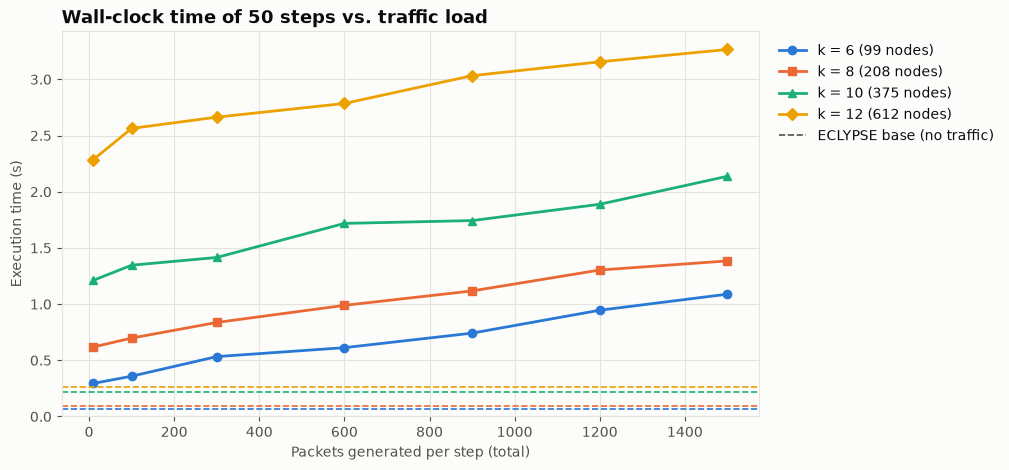

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
for k, group in results.groupby("k"):
    style = K_STYLE[k]
    ax.plot(group["rate"], group["net_s"], color=style["color"], marker=style["marker"], lw=2, label=k_label(k))
    ax.axhline(group["base_s"].iloc[0], color=style["color"], lw=1.2, ls="--")
ax.set_title("Wall-clock time of 50 steps vs. traffic load", loc="left")
ax.set_xlabel("Packets generated per step (total)")
ax.set_ylabel("Execution time (s)")
ax.set_ylim(bottom=0)
handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([], [], color=TEXT_MUTED, ls="--", lw=1.2))
labels.append("ECLYPSE base (no traffic)")
ax.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.show()

How much the time grows with the load (from the lightest to the heaviest) and with the
size of the topology (from the smallest to the largest):

In [8]:
net = results.pivot(index="rate", columns="k", values="net_s")
print("Growth with the load, per topology:")
print((net.loc[max(RATES)] / net.loc[min(RATES)]).round(2).to_string())
print("\nGrowth with the size of the topology, per load:")
print((net[max(K_VALUES)] / net[min(K_VALUES)]).round(2).to_string())

Growth with the load, per topology:
k
6     3.70
8     2.24
10    1.76
12    1.43

Growth with the size of the topology, per load:
rate
10      7.77
100     7.15
300     5.00
600     4.55
900     4.09
1200    3.34
1500    3.00


The size of the topology matters much more than the load: 150 times more traffic
increases the time by a small factor, while going from `k = 6` to `k = 12` (six times
more nodes) multiplies it several times. The next charts break down where the time goes.

## 2. Where the time goes

Each bar splits the time of one run into:

- **routing, first step** — the first call of the routing event, which also builds the
  forwarding tables (all-pairs minimum-cost paths); a fixed cost per topology;
- **routing, other steps** — the forwarding of the packets in the other 49 steps;
- **generation** — Poisson traffic generation;
- **placement audit** — the ECLYPSE check of the placement requirements, including the
  recomputation of the paths of the application links;
- **other** — everything else: the ECLYPSE simulation loop, the telemetry metric and
  the reports.

The two bars of each topology are the lightest and the heaviest load.

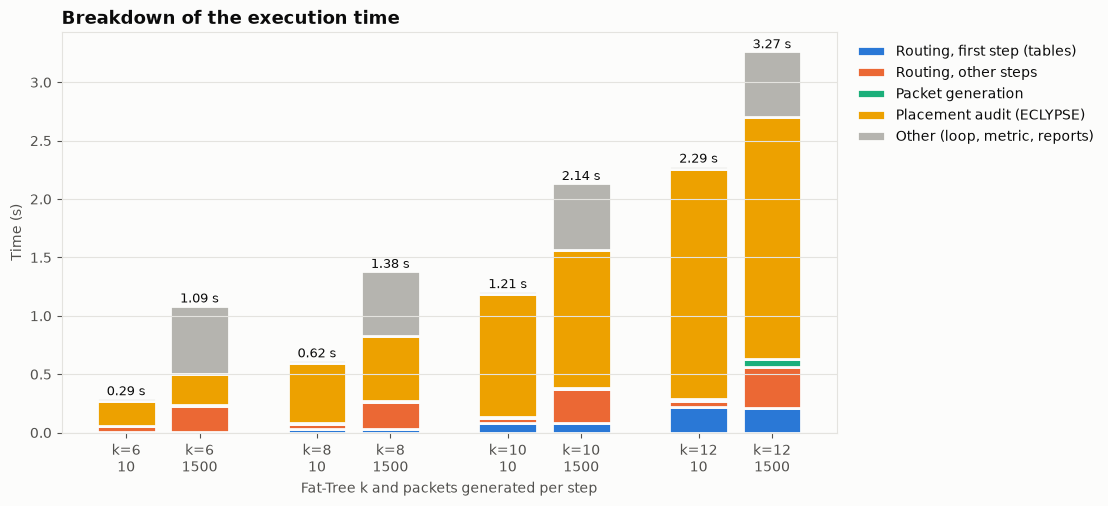

Share of the execution time (%):
 k  rate  Routing, first step (tables)  Routing, other steps  Packet generation  Placement audit (ECLYPSE)  Other (loop, metric, reports)
 6    10                           2.8                  15.1                1.7                       71.7                            8.6
 6  1500                           0.8                  20.1                0.7                       24.4                           54.0
 8    10                           4.3                   7.4                1.1                       83.1                            4.1
 8  1500                           2.2                  17.0                0.7                       39.7                           40.4
10    10                           6.8                   3.7                0.7                       86.5                            2.2
10  1500                           3.8                  13.6                0.6                       55.2                           26.9
1

In [9]:
COMPONENTS = [
    ("routing_first_s", "Routing, first step (tables)", "#2a78d6"),
    ("routing_rest_s", "Routing, other steps", "#eb6834"),
    ("generation_s", "Packet generation", "#1baf7a"),
    ("audit_s", "Placement audit (ECLYPSE)", "#eda100"),
    ("other_s", "Other (loop, metric, reports)", "#b5b4af"),
]
results["other_s"] = results["net_s"] - results[["routing_first_s", "routing_rest_s", "generation_s", "audit_s"]].sum(axis=1)

extremes = results[results["rate"].isin([min(RATES), max(RATES)])].reset_index(drop=True)
labels = [f"k={r.k}\n{r.rate}" for r in extremes.itertuples()]
x = np.arange(len(extremes)) + np.repeat(np.arange(len(K_VALUES)) * 0.6, 2)

fig, ax = plt.subplots(figsize=(10, 5.2))
bottom = np.zeros(len(extremes))
for column, label, color in COMPONENTS:
    ax.bar(x, extremes[column], bottom=bottom, width=0.8, color=color, edgecolor=SURFACE, linewidth=2, label=label)
    bottom += extremes[column].to_numpy()
for xi, total in zip(x, bottom):
    ax.text(xi, total, f"{total:.2f} s", ha="center", va="bottom", color=TEXT, fontsize=9)
ax.set_xticks(x, labels)
ax.set_xlabel("Fat-Tree k and packets generated per step")
ax.set_title("Breakdown of the execution time", loc="left")
ax.set_ylabel("Time (s)")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.show()

share = extremes[["k", "rate"]].copy()
for column, label, _ in COMPONENTS:
    share[label] = (100 * extremes[column] / extremes["net_s"]).round(1)
print("Share of the execution time (%):")
print(share.to_string(index=False))

## 3. The placement audit

At every step ECLYPSE audits the placement: for each application link it retrieves the
infrastructure path between the two services and checks its latency and bandwidth. In
the base simulation the application has no links, so the audit only checks node
resources. In Eclypse+NET the source service has one link to every other host.

ECLYPSE caches these paths, but every write of a link `latency` attribute invalidates the
whole cache, and the routing event writes the latency of the links it used at every
step. As a result, every path is recomputed at every check, whatever the load: this is
a cost of the integration between the extension and the framework, not of the packet
model. The table counts the path computations.

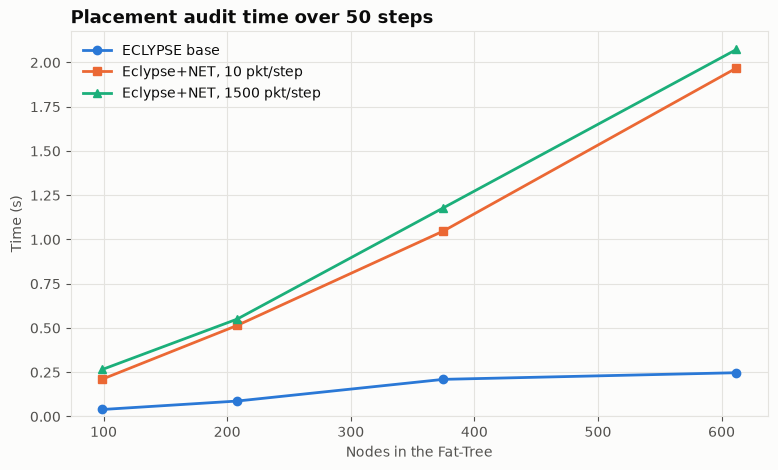

 k  rate  audit_s  path_s  path_calls  app_links  path computations per step  audit share (%)
 6    10    0.211   0.054      6700.0         53                       134.0           71.701
 6  1500    0.266   0.079      6700.0         53                       134.0           24.409
 8    10    0.514   0.145     14950.0        127                       299.0           83.122
 8  1500    0.550   0.152     14950.0        127                       299.0           39.725
10    10    1.048   0.322     28250.0        249                       565.0           86.503
10  1500    1.179   0.323     28250.0        249                       565.0           55.165
12    10    1.969   0.712     47700.0        431                       954.0           86.112
12  1500    2.073   0.779     47700.0        431                       954.0           63.490


In [10]:
AUDIT = [
    ("ECLYPSE base", "#2a78d6", "o", results[results["rate"] == RATES[0]].set_index("nodes")["base_audit_s"]),
    (f"Eclypse+NET, {RATES[0]} pkt/step", "#eb6834", "s", results[results["rate"] == RATES[0]].set_index("nodes")["audit_s"]),
    (f"Eclypse+NET, {RATES[-1]} pkt/step", "#1baf7a", "^", results[results["rate"] == RATES[-1]].set_index("nodes")["audit_s"]),
]
fig, ax = plt.subplots(figsize=(9, 5))
for label, color, marker, series in AUDIT:
    ax.plot(series.index, series.to_numpy(), color=color, marker=marker, lw=2, label=label)
ax.set_title("Placement audit time over 50 steps", loc="left")
ax.set_xlabel("Nodes in the Fat-Tree")
ax.set_ylabel("Time (s)")
ax.set_ylim(bottom=0)
ax.legend(loc="upper left")
plt.show()

audit = results[["k", "rate", "audit_s", "path_s", "path_calls"]].copy()
audit["app_links"] = results["k"] ** 3 // 4 - 1
audit["path computations per step"] = audit["path_calls"] / SIM_STEPS
audit["audit share (%)"] = 100 * results["audit_s"] / results["net_s"]
print(audit[audit["rate"].isin([RATES[0], RATES[-1]])].round(3).to_string(index=False))

## 4. Per-step routing time

The routing time of every step for the largest topology. The first step is the outlier
that includes the construction of the forwarding tables; after it, the time per step
settles to a value that grows with the load. The y axis is logarithmic.

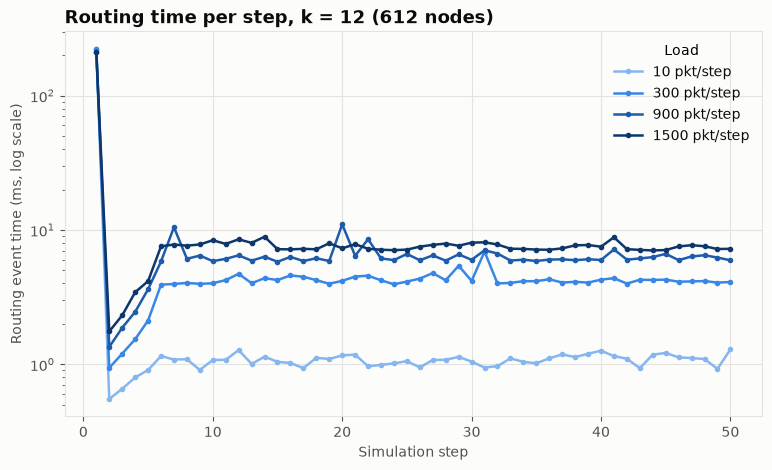

      first step (ms)  median other steps (ms)  median hops per step
rate                                                                
10             220.84                     1.08                  56.0
100            214.01                     2.77                 562.0
300            222.51                     4.16                1740.0
600            216.84                     5.23                3520.0
900            210.77                     6.06                5227.0
1200           231.67                     6.76                7014.0
1500           210.96                     7.51                8718.0


In [11]:
K_MAX = max(K_VALUES)
SHOWN_RATES = [RATES[0], RATES[2], RATES[4], RATES[-1]]
RAMP = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]  # light = low load

fig, ax = plt.subplots(figsize=(9, 5))
for rate, color in zip(SHOWN_RATES, RAMP):
    data = per_step[(per_step["k"] == K_MAX) & (per_step["rate"] == rate)]
    ax.plot(data["step"], data["routing_ms"], color=color, lw=1.8, marker="o", ms=3, label=f"{rate} pkt/step")
ax.set_yscale("log")
ax.set_title(f"Routing time per step, {k_label(K_MAX)}", loc="left")
ax.set_xlabel("Simulation step")
ax.set_ylabel("Routing event time (ms, log scale)")
ax.legend(title="Load", loc="upper right", title_fontsize=10)
plt.show()

steady = per_step[(per_step["k"] == K_MAX) & (per_step["step"] > 1)].groupby("rate")
summary = pd.DataFrame({
    "first step (ms)": per_step[(per_step["k"] == K_MAX) & (per_step["step"] == 1)].set_index("rate")["routing_ms"],
    "median other steps (ms)": steady["routing_ms"].median(),
    "median hops per step": steady["hops"].median(),
})
print(summary.round(2).to_string())

## 5. Cost per simulated hop

The routing time of the steps after the first, divided by the number of hops they
simulate. Forwarding is vectorised over all the packets of a step, so the fixed cost of
a step (one call per router, array allocations) is shared by more packets as the load
grows, and the cost per hop falls. Both axes are logarithmic.

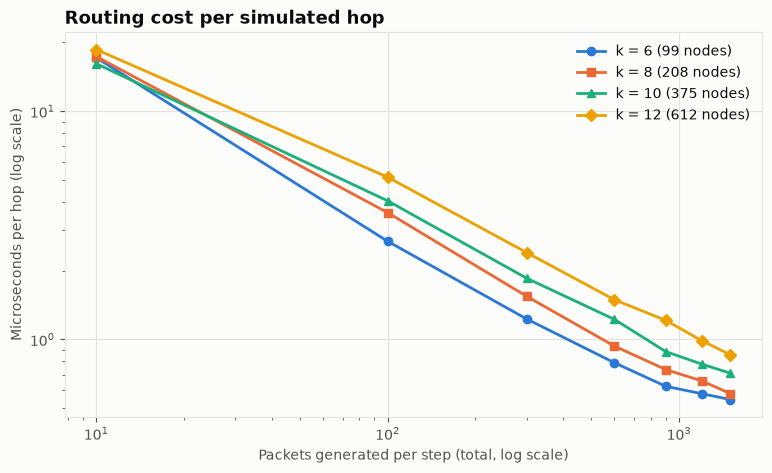

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
for k, group in results.groupby("k"):
    style = K_STYLE[k]
    ax.plot(group["rate"], group["us_per_hop"], color=style["color"], marker=style["marker"], lw=2, label=k_label(k))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Routing cost per simulated hop", loc="left")
ax.set_xlabel("Packets generated per step (total, log scale)")
ax.set_ylabel("Microseconds per hop (log scale)")
ax.legend(loc="upper right")
plt.show()

## 6. Simulation throughput

The same measurement read as throughput: hops simulated per second of routing time.

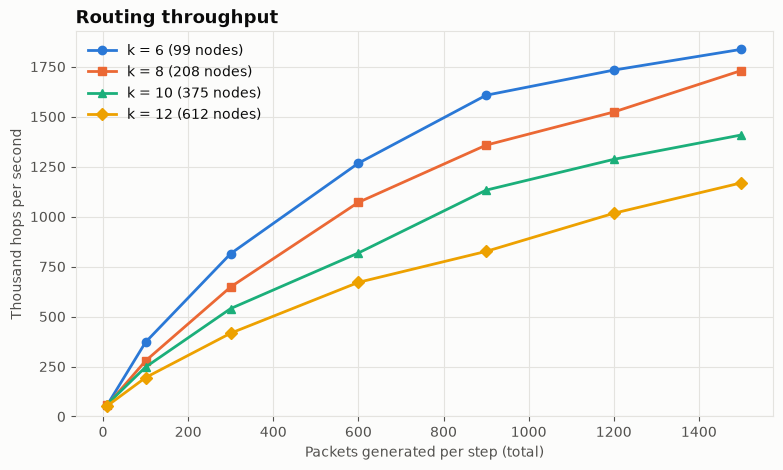

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
for k, group in results.groupby("k"):
    style = K_STYLE[k]
    ax.plot(group["rate"], group["hops_per_s"] / 1e3, color=style["color"], marker=style["marker"], lw=2, label=k_label(k))
ax.set_title("Routing throughput", loc="left")
ax.set_xlabel("Packets generated per step (total)")
ax.set_ylabel("Thousand hops per second")
ax.set_ylim(bottom=0)
ax.legend(loc="upper left")
plt.show()

## 7. Scaling with the size of the network

Execution time against the number of nodes, for the base simulation and for the
lightest and heaviest load, together with the time of the first routing step alone.

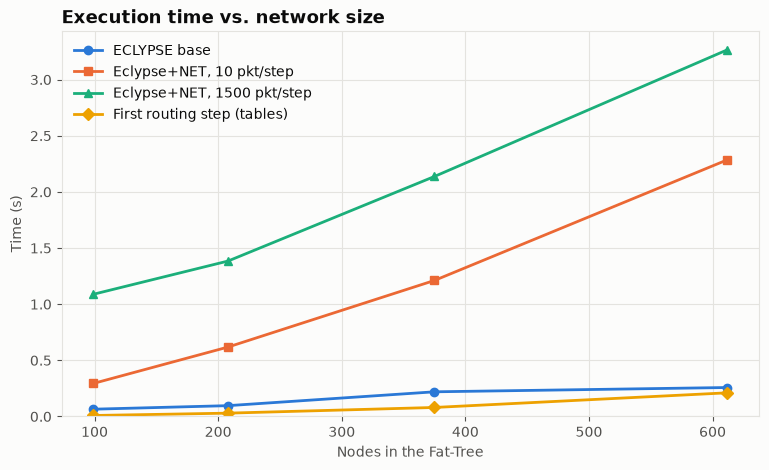

       ECLYPSE base  Eclypse+NET, 10 pkt/step  Eclypse+NET, 1500 pkt/step  First routing step (tables)
nodes                                                                                                 
99            0.065                     0.294                       1.088                        0.009
208           0.097                     0.619                       1.384                        0.030
375           0.220                     1.212                       2.137                        0.080
612           0.258                     2.286                       3.266                        0.211


In [14]:
SCALING = [
    ("ECLYPSE base", "#2a78d6", "o", results[results["rate"] == RATES[0]].set_index("nodes")["base_s"]),
    (f"Eclypse+NET, {RATES[0]} pkt/step", "#eb6834", "s", results[results["rate"] == RATES[0]].set_index("nodes")["net_s"]),
    (f"Eclypse+NET, {RATES[-1]} pkt/step", "#1baf7a", "^", results[results["rate"] == RATES[-1]].set_index("nodes")["net_s"]),
    ("First routing step (tables)", "#eda100", "D", results[results["rate"] == RATES[-1]].set_index("nodes")["routing_first_s"]),
]
fig, ax = plt.subplots(figsize=(9, 5))
for label, color, marker, series in SCALING:
    ax.plot(series.index, series.to_numpy(), color=color, marker=marker, lw=2, label=label)
ax.set_title("Execution time vs. network size", loc="left")
ax.set_xlabel("Nodes in the Fat-Tree")
ax.set_ylabel("Time (s)")
ax.set_ylim(bottom=0)
ax.legend(loc="upper left")
plt.show()

print(pd.DataFrame({label: series for label, _, _, series in SCALING}).round(3).to_string())

## 8. Packet drops

With queues of 100 000 packets and 1 Gbps links, the load of the benchmark never fills
a queue: the table below should contain only zeros. Drops would appear by lowering
`max_queue_size`, since the packets that reach a link in the same step are enqueued
together.

In [15]:
print(results.pivot(index="rate", columns="k", values="dropped").to_string())

k      6    8    10   12
rate                    
10    0.0  0.0  0.0  0.0
100   0.0  0.0  0.0  0.0
300   0.0  0.0  0.0  0.0
600   0.0  0.0  0.0  0.0
900   0.0  0.0  0.0  0.0
1200  0.0  0.0  0.0  0.0
1500  0.0  0.0  0.0  0.0


## Takeaways

- **The packet model is not the bottleneck.** After the first step, the routing event
  takes a minor share of the run, and its cost per hop decreases as the load grows,
  because all the packets of a step are forwarded in vectorised form.
- **The placement audit of ECLYPSE is the largest cost.** Every latency update
  invalidates the path cache of the framework, so the paths of all the application links
  are recomputed at every check. The cost grows with the number of nodes and of
  application links, not with the traffic. Since `Network` routes on the inverse
  bandwidth, latency changes never change a path: the invalidation could be avoided.
- **Building the forwarding tables is a one-off cost** of the first step, which grows
  faster than linearly with the number of nodes.
- **Telemetry grows with the traffic.** The "other" share grows with the load because
  the metric reports one row per hop.